# SnowEnergyBalance and Meteorology Components Tutorial
(Tian Gan, Sept 2024)

This tutorial demonstrates how to couple the Meteorology component with the SnowEnergyBalance component to simulate the snow accumulation and snowmelt process for a study area in Colorado. It includes the following sections:

- Component introduction
- Prepare model inputs
- Model simulation 
- Results analysis

## Component introduction

### SnowEnergyBalance component

SnowEnergyBalance component accounts for energy fluxes (e.g., short wave radiation, long wave radiation, sensible heat, latent heat) to simulate snowpack dynamics. This component uses the net total energy flux (q_sum) and the snowpack cold content to determine the snow melt rate:
- If the net total energy (q_sum * time) is larger than cold content, the melt process starts using the remaining energy (q_sum * time - cold_content).
- If the net total energy is positive but less than cold content, the snowpack is warming and the cold content decreases.
- If the total energy is negative, the snow is cooling and the cold content increases.

q_sum is the sum of the various net energy fluxes from net short wave radiation, long wave radition, sensible heat, and latent heat, etc.
q_sum can be estimated using the Meterology comopnent or provided by users as input data. 

cold_content can be estimated as:

$cold\_content = rho\_snow * cp\_snow * (melting\_point - snow\_temp) * h\_snow$
- rho_snow: snow density
- cp_snow: snow heat capacity
- melting_point: snow melting point temperature
- snow_temp: snowpack average temperature
- h_snow: snow depth

<!-- $Q\_sum = Qn\_SW + Qn\_LW + Qh + Qe + Qa + Qc$

* Qn_SW: net short wave energy flux
* Qn_LW: net long wave energy flux
* Qh: sensible heat energy flux
* Qe: latent heat energy flux
* Qa: net energy flux advected by moving water (assume this to be negligible; Qa=0)
* Qc: net energy flux via conduction from snow to soil (assume this to be negligible; Qc=0) -->

To get an overview of the component, we can examine its *header docstring*, which is the internal documentation provided in the form of a Python docstring that sits just below the class declaration in the source code:

In [ ]:
from landlab.components import SnowEnergyBalance

help(SnowEnergyBalance)

Now, let's check about the input and output data fields for this component. 

In [ ]:
# input
SnowEnergyBalance.input_var_names

In [ ]:
# optional input
SnowEnergyBalance.optional_var_names

In [ ]:
# output
SnowEnergyBalance.output_var_names

In [ ]:
# units
SnowEnergyBalance.units

### Meteorology component

Meteorology component calculates several energy fluxes (e.g., solar radiation, longwave radiation, sensible heat, latent heat) to estimate the net total energy flux(Q_sum):

$Q\_sum = Qn\_SW + Qn\_LW + Qh + Qe + Qa + Qc$

* Qn_SW: net shortwave energy flux
* Qn_LW: net longwave energy flux
* Qh: sensible heat energy flux
* Qe: latent heat energy flux
* Qa: net energy flux advected by moving water (assume this to be negligible; Qa=0)
* Qc: net energy flux via conduction from snow to soil (assume this to be negligible; Qc=0)

To get an overview of the component, we can examine its *header docstring*, which is the internal documentation provided in the form of a Python docstring that sits just below the class declaration in the source code:

In [ ]:
from landlab.components import Meteorology

help(Meteorology)

Now, let's check about the input and output data fields for this component. 

In [ ]:
# input
Meteorology.input_var_names

In [ ]:
# optional input
Meteorology.optional_var_names

In [ ]:
# output
Meteorology.output_var_names

In [ ]:
# units
Meteorology.units

## Prepare model inputs

We choose the Gunnison River Basin in Colorado as the study area (bounding box [-109.0, 39.5, -106, 37.5]). We will use the ERA5 hourly climate dataset with data resolution of ~31km for May 1-7, 2023 as the model inputs. (Image source: https://gunnisonriverbasin.org/water-plans-management/water-management/)

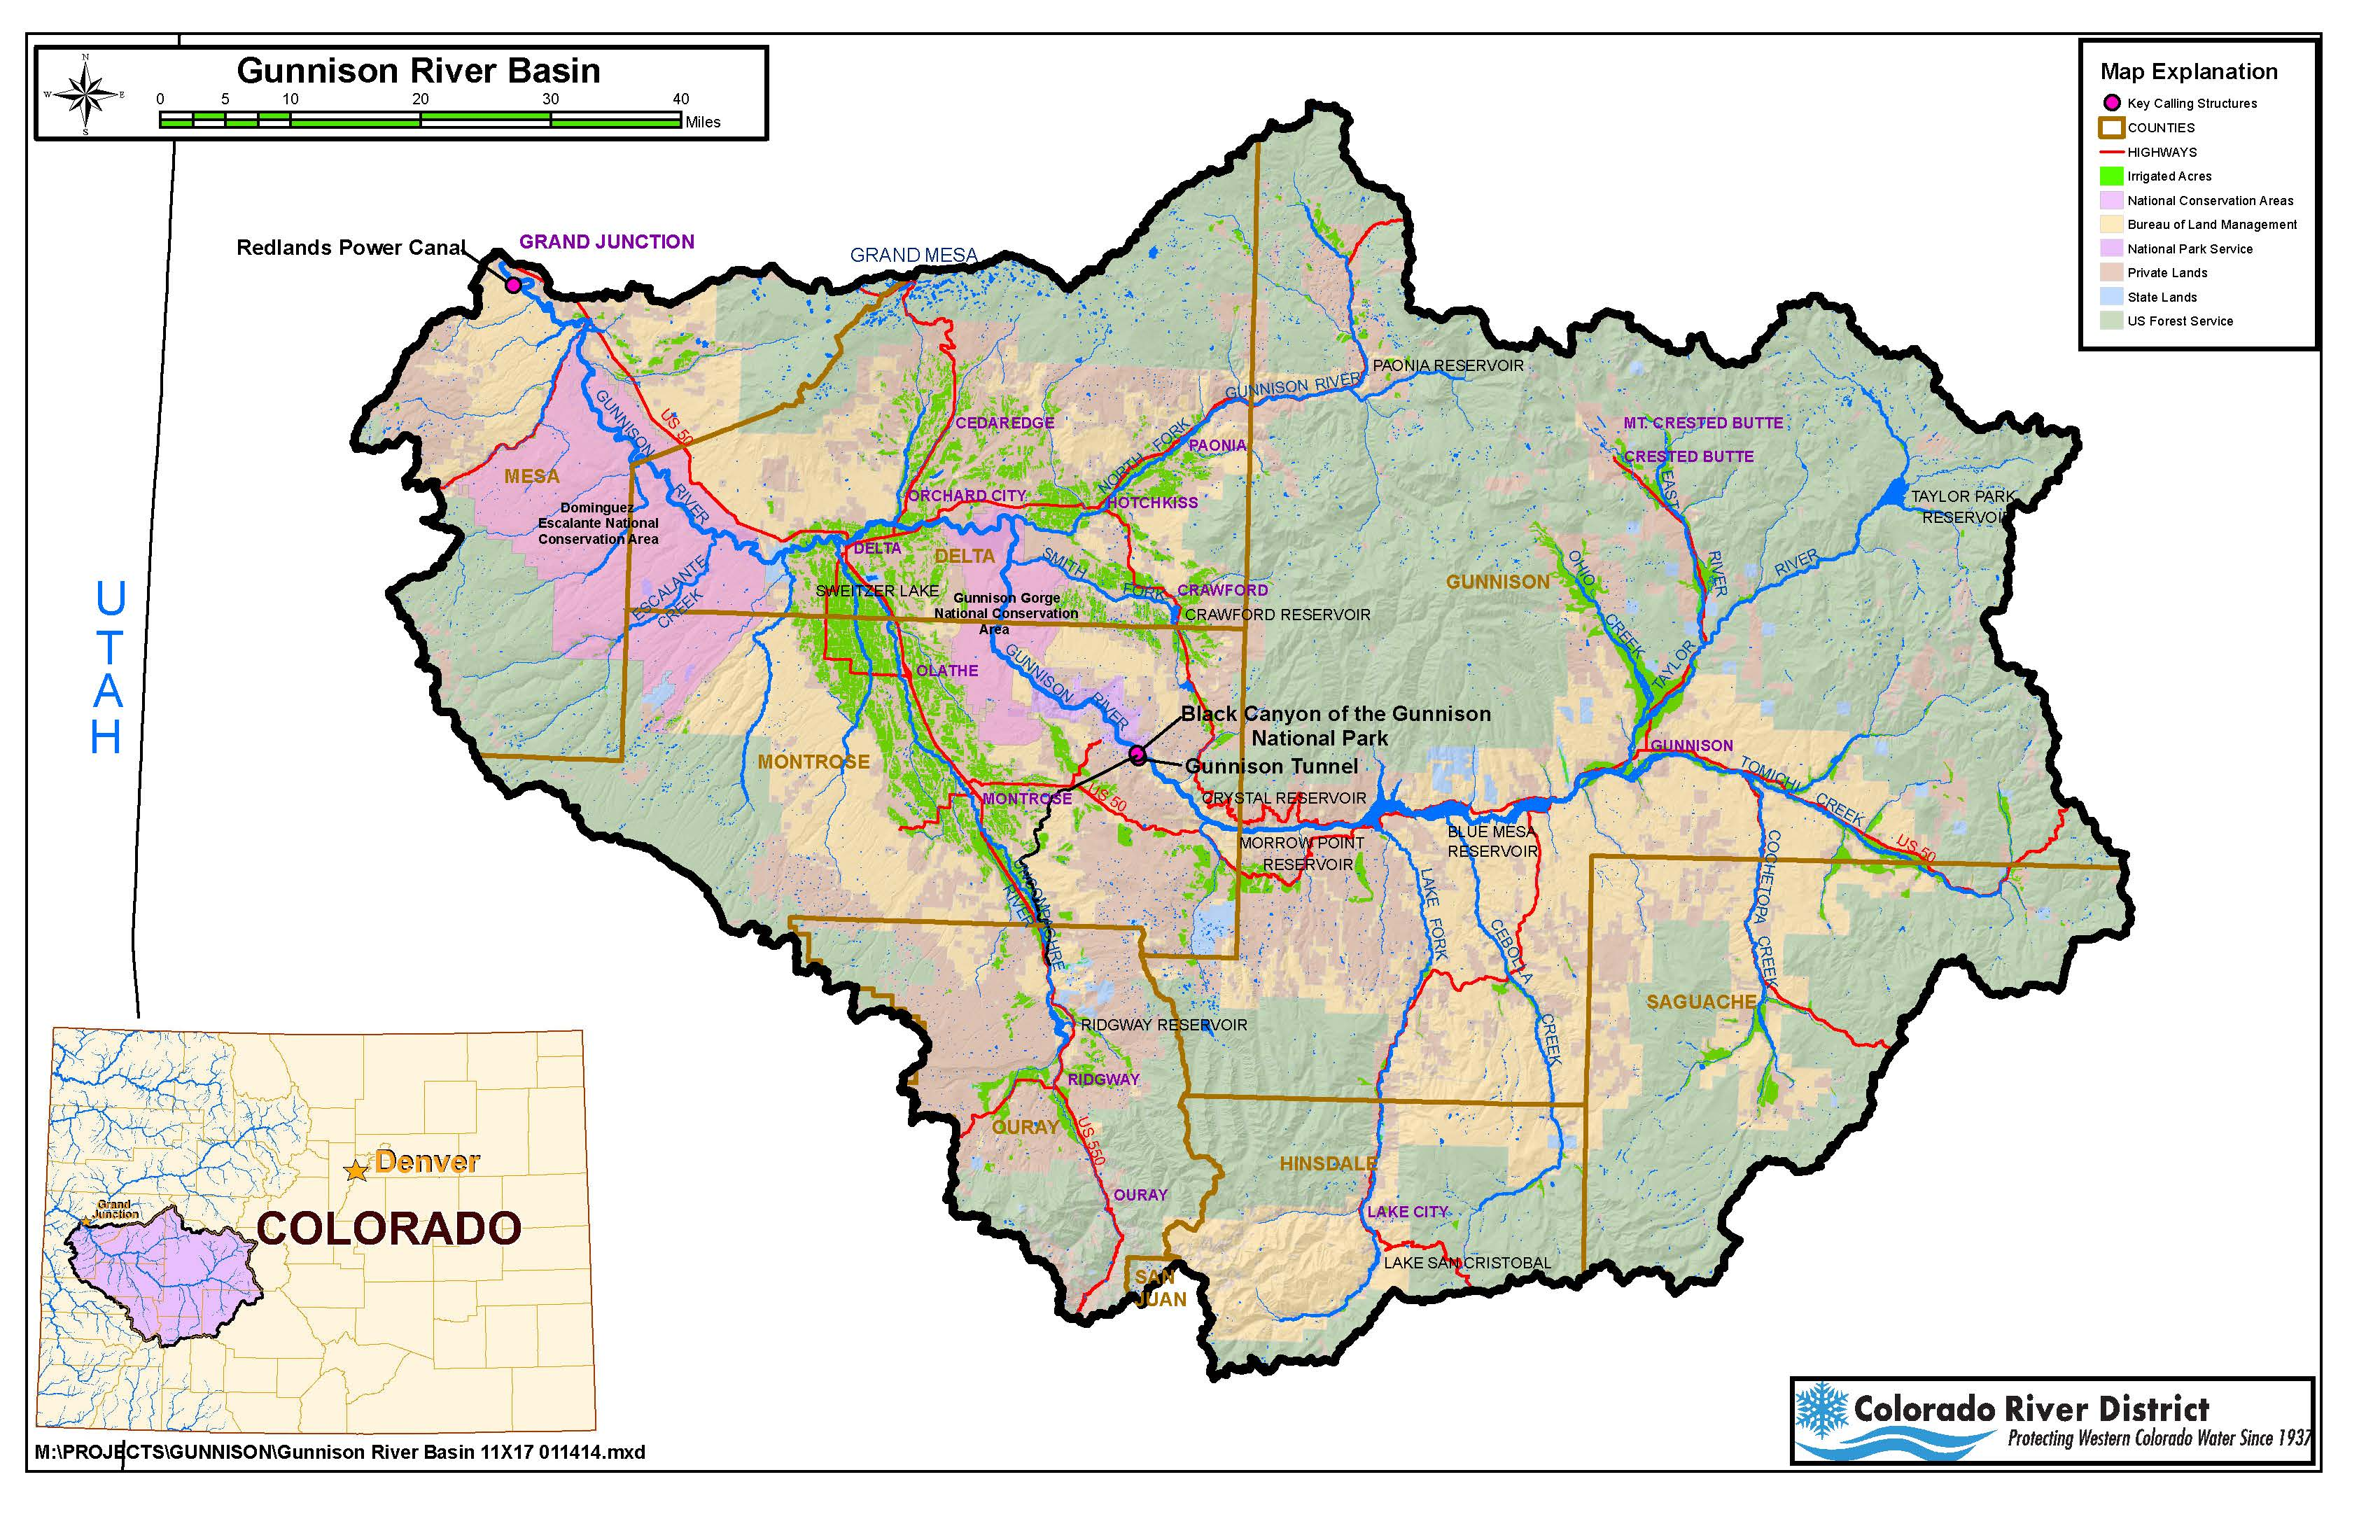

### Load dataset
The ERA5 dataset is already downloaded for the study area. Now let's load the NetCDF file and plot the dataset. In this example, we will use the following variables: 
- total precipitation ("tp")
- 2m temperature ("t2m")
- snow depth ("sd")
- snow albedo ("asn")
- snow density ("rsn")
- temperature of snow layer ("tsn")
- 10m u component of wind ("u10")
- 10m v component of wind ("v10")
- total cloud cover ("tcc")
- high vegetation cover ("cvh")

In [ ]:
# load dataset
import xarray as xr

era5 = xr.open_dataset("era5.nc")
print(era5)

In [ ]:
# plot ERA5 dataset (at the first time step)
import numpy as np
from matplotlib import pyplot as plt

var_names = era5.data_vars

fig = plt.figure(figsize=(16, 24))
nrows, ncols = 5, 2
i = 1

for var_name in var_names:
    # get metadata
    var_unit = era5[var_name].units
    var_long_name = era5[var_name].long_name
    var_shape = era5[var_name].shape

    # get data
    data_2D = era5[var_name].values[0]

    # plot data
    ax = fig.add_subplot(nrows, ncols, i)
    im = ax.imshow(data_2D, cmap="Blues")
    ax.title.set_text(f"{var_long_name} ({var_unit})")
    ax.set_yticks(np.arange(0, len(era5["latitude"])))
    ax.set_yticklabels(era5["latitude"].values, fontsize=7)
    ax.set_xticks(np.arange(0, len(era5["longitude"])))
    ax.set_xticklabels(era5["longitude"].values, fontsize=7)
    ax.set_xlabel("longitude [degree_east]")
    ax.set_ylabel("latitude [degree_north]")
    cbar = plt.colorbar(im, ax=ax)

    i += 1

### Define model grid 

We will first define a RasterModelGrid for the study area. The model grid shape will be defined based on the ERA5 dataset. Then, we will assign the ERA5 variables as the input data fields for the Meteorology and SnowEnergyBalance components. We will use the snow depth (in water equivalent) at the first time step from ERA5 dataset as the initial input for `snowpack__liquid-equivalent_depth`. This initial snow depth input will also be used for model analysis in the later section.

In [ ]:
from landlab import RasterModelGrid

grid_shape = var_shape[1:]
grid = RasterModelGrid(grid_shape, xy_spacing=(31000, 31000))

In [ ]:
# add air temperature field
t_air = grid.add_zeros("atmosphere_bottom_air__temperature", at="node", clobber=True)
t_air[:] = era5["t2m"].values[0].flatten() - 273.15  # units: K to C

In [ ]:
# add initial snow water equivalent
h_swe = grid.add_zeros("snowpack__liquid-equivalent_depth", at="node", clobber=True)
h_swe[:] = era5["sd"].values[0].flatten()

# store the initial swe for results analysis
init_swe = era5["sd"].values[0].flatten()

In [ ]:
# add snow surface temperature field
T_surf = grid.add_zeros("land_surface__temperature", at="node", clobber=True)
T_surf[:] = era5["tsn"].values[0].flatten() - 273.15  # units: K to C

In [ ]:
# add precipitation field
p = grid.add_zeros(
    "atmosphere_water__precipitation_leq-volume_flux", at="node", clobber=True
)
p[:] = era5["tp"].values[0].flatten() / 3600  # units: m/hr to m/s

In [ ]:
# add snow density field
rho_snow = grid.add_zeros(
    "snowpack__z_mean_of_mass-per-volume_density", at="node", clobber=True
)
rho_snow[:] = era5["rsn"].values[0].flatten()

In [ ]:
# add initial snowpack depth field
h_snow = grid.add_zeros("snowpack__depth", at="node", clobber=True)
h_snow[:] = h_swe * 1000 / rho_snow

In [ ]:
# add albedo field
albedo = grid.add_zeros("land_surface_albedo", at="node", clobber=True)
albedo[:] = era5["asn"].values[0].flatten()

In [ ]:
# add wind speed field
u_wind = era5["u10"].values[0].flatten()
v_wind = era5["v10"].values[0].flatten()

uz = grid.add_zeros(
    "atmosphere_bottom_air_flow__reference-height_speed", at="node", clobber=True
)
uz[:] = (u_wind**2 + v_wind**2) ** 0.5

In [ ]:
# add canopy factor field
canopy_factor = grid.add_zeros(
    "atmosphere_bottom_air__brutsaert_emissivity_canopy_factor", at="node", clobber=True
)
canopy_factor[:] = era5["cvh"].values[0].flatten()

In [ ]:
# add cloud factor field
cloud_factor = grid.add_zeros(
    "atmosphere_bottom_air__brutsaert_emissivity_cloud_factor", at="node", clobber=True
)
cloud_factor[:] = era5["tcc"].values[0].flatten()

Let's add latitude and longitude fields in the model grid.

In [ ]:
# get ERA5 data coordinates
import numpy as np

era5_y = era5["latitude"].values
era5_x = era5["longitude"].values

# create latitude and longitude values
lat_grid = np.array([era5_y] * len(era5_x)).T
lon_grid = np.array([era5_x] * len(era5_y))

# add latitude and longitude field
lat_deg = grid.add_field("land_surface__latitude", lat_grid, at="node", clobber=True)
lon_deg = grid.add_field("land_surface__longitude", lon_grid, at="node", clobber=True)

## Model simulation

We will initialize an instance for Meteorology and SnowEnergyBalance components. The simulation time will be 168hr (May 1-7, 2023) and the time step is 1hr. At each time step, we will use the ERA5 dataset to update the values for several input data fields. 

In [ ]:
# initialize an instance for model components
from landlab.components import SnowEnergyBalance

met = Meteorology(
    grid, start_datetime="2023-04-30 17:00:00", gmt_offset=-7
)  # local time
seb = SnowEnergyBalance(grid)

In [ ]:
# run model
from tqdm import trange

dt = 3600  # sec
time_steps = 167
i = 1

for time_step in trange(0, time_steps):
    # run model
    met.run_one_step(dt)
    seb.run_one_step(dt)

    # update input
    if time_step < time_steps - 1:
        # update dataset
        i += 1

        # assign P
        p[:] = era5["tp"].values[i].flatten() / 3600  # units: m/hr to m/s

        # assign T_air
        t_air[:] = era5["t2m"].values[i].flatten() - 273.15  # units: K to C

        # assign T_surf
        T_surf[:] = era5["tsn"].values[i].flatten() - 273.15  # units: K to C

        # assign albedo
        albedo[:] = era5["asn"].values[i].flatten()

        # assign rho_snow
        rho_snow[:] = era5["rsn"].values[i].flatten()

        # assign uz
        u_wind = era5["u10"].values[i].flatten()
        v_wind = era5["v10"].values[i].flatten()
        uz[:] = (u_wind**2 + v_wind**2) ** 0.5

        # assign cloud_factor
        cloud_factor[:] = era5["tcc"].values[i].flatten()

        # assign canopy_factor
        canopy_factor[:] = era5["cvh"].values[i].flatten()

## Results analysis

Now, let’s create some plots to visualize the results. We will compare the initial snow water equivalent (SWE) at the first time step with the simulated SWE and the ERA5 SWE data at the last time step. The plots reveal notable differences in the snowmelt patterns between the simulated SWE and the ERA5 data. These discrepancies are primarily attributed to the differing functions used to estimate the snowmelt process and energy fluxes for ERA5 compared to the two model components.

In [ ]:
fig = plt.figure(figsize=(18, 10))
nrows, ncols = 2, 2
j = 1

sim_swe = grid.at_node["snowpack__liquid-equivalent_depth"]
era5_swe = era5["sd"].values[i].flatten()

diff_swe_sim = init_swe - sim_swe
diff_swe_era5 = init_swe - era5_swe

plot_data = [
    era5_swe,
    sim_swe,
    diff_swe_era5,
    diff_swe_sim,
]
titles = [
    "ERA5 SWE",
    "SnowDegreeDay SWE",
    "SWE Difference ERA5",
    "SWE Difference SDD",
]
for title, data in zip(titles, plot_data):
    ax = fig.add_subplot(nrows, ncols, j)

    # get variable data
    data_2D = data.reshape(grid_shape)

    # plot data
    im = ax.imshow(
        data_2D, cmap="Blues", vmax=0.2 if "SWE Difference" in title else 0.4
    )
    ax.title.set_text(title)
    cbar = plt.colorbar(im, ax=ax)

    j += 1